**Import library**

- `random`, `numpy`, `pandas`: bilang acak, hitungan angka, dan tabel data.
- `scipy.stats`: uji statistik (t-test, chi-square, ANOVA).
- `statsmodels`: uji statistik lain dan analisis power/ukuran sampel.
- `matplotlib`: grafik.
- `%matplotlib inline`: grafik ditampilkan langsung di bawah sel.

In [ ]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

**Memuat data**

Empat dataset dibaca dari GitHub:
- `session_times`: lama kunjungan (session) di dua halaman web, Page A dan Page B.
- `four_sessions`: lama kunjungan di empat halaman (Page 1 sampai Page 4).
- `click_rate`: jumlah klik dan tidak klik untuk tiga judul berita (Headline A, B, C).
- `imanishi`: frekuensi kemunculan tiap digit pada suatu data.

In [ ]:
WEB_PAGE_DATA_CSV = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv"
FOUR_SESSIONS_CSV = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/four_sessions.csv"
CLICK_RATE_CSV = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/click_rates.csv"
IMANISHI_CSV = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/imanishi_data.csv"
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)
click_rate = pd.read_csv(CLICK_RATE_CSV)
imanishi = pd.read_csv(IMANISHI_CSV)

**A/B test** adalah eksperimen dengan dua kelompok untuk menentukan mana yang lebih baik di antara dua perlakuan, produk, atau prosedur.

**Mengubah satuan waktu**

Kolom `Time` dikalikan 100 supaya satuannya menjadi detik, sesuai label grafik berikutnya. Sel ini tidak menampilkan apa-apa, hanya mengubah data di memori. Jangan dijalankan dua kali, karena nilainya akan dikalikan 100 lagi.

In [ ]:
session_times.Time = 100 * session_times.Time

**Boxplot waktu kunjungan Page A vs Page B**

Boxplot meringkas sebaran data: garis tengah kotak adalah median, kotak mencakup 50% data di tengah, dan titik di luar "kumis" adalah nilai yang tampak ekstrem. Dari sini bisa dilihat sekilas apakah lama kunjungan kedua halaman berbeda.

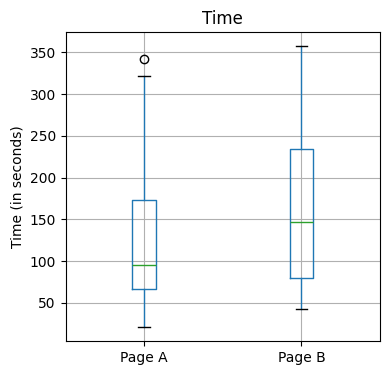

In [ ]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

**Selisih rata-rata yang teramati**

Menghitung rata-rata waktu kunjungan Page A dan Page B, lalu selisihnya (B dikurangi A). Hasilnya sekitar 35,67 detik, artinya rata-rata pengunjung Page B tinggal 35,67 detik lebih lama. Pertanyaannya: apakah selisih ini nyata, atau hanya kebetulan? Itu yang diuji dengan sel-sel berikutnya.

In [ ]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


**Fungsi permutation test**

Ide permutation test: jika kedua halaman sebenarnya sama saja, label "A" dan "B" boleh diacak tanpa mengubah apa pun. Fungsi `perm_fun`:
1. Memilih secara acak `nB` data dan menyebutnya kelompok B, sisanya kelompok A.
2. Mengembalikan selisih rata-rata kedua kelompok acak itu.

`nA` dan `nB` adalah jumlah data asli di tiap halaman. Satu kali pengacakan di sini menghasilkan selisih sekitar -52,10 detik. Angkanya berubah tiap dijalankan karena acak.

In [ ]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

-52.1047619047619


**Distribusi selisih hasil pengacakan**

Pengacakan diulang 1000 kali, lalu semua selisihnya digambar sebagai histogram. Histogram ini menunjukkan selisih yang wajar muncul karena kebetulan saja. Garis hitam adalah selisih asli (35,67 detik). Jika garis hitam berada di tengah sebaran, selisih asli mudah terjadi secara kebetulan. Jika jauh di ujung, selisih itu kemungkinan nyata. `random.seed(1)` membuat hasil bisa diulang.

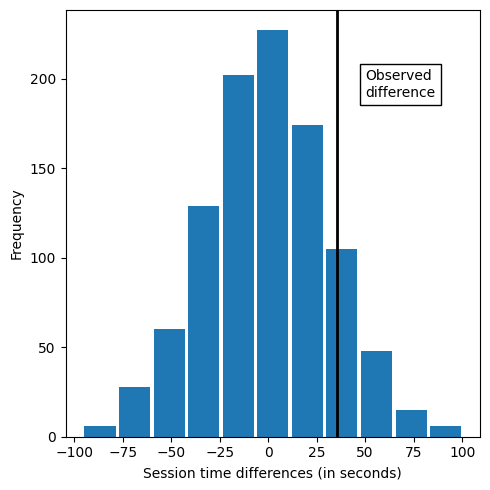

In [ ]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Menghitung p-value dari permutation test**

Menghitung proporsi hasil pengacakan yang selisihnya lebih besar dari selisih asli. Hasilnya 0,121, artinya sekitar 12,1% pengacakan menghasilkan selisih sebesar itu atau lebih besar hanya karena kebetulan. Itu di atas batas umum 0,05, jadi perbedaan Page A dan B **belum cukup meyakinkan** secara statistik.

In [ ]:

# convert perm_diffs to numpy array to avoid problems with some Python installations
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


**Permutation test untuk conversion rate**

Data: Price A menghasilkan 200 konversi dari 23.739 pengunjung, Price B 182 dari 22.588.
- `obs_pct_diff`: selisih conversion rate dalam persen (sekitar 0,0368%).
- `conversion`: daftar 0 dan 1 untuk semua 46.327 pengunjung (1 = konversi, 382 orang). Daftar ini dibuat terpisah dari data asli karena hanya jumlah 0 dan 1 yang diperlukan.
- Seperti sebelumnya, data diacak 1000 kali memakai `perm_fun`, selisihnya dikali 100 agar dalam persen, lalu digambar sebagai histogram. Garis hitam adalah selisih yang teramati.

Observed difference: 0.0368%


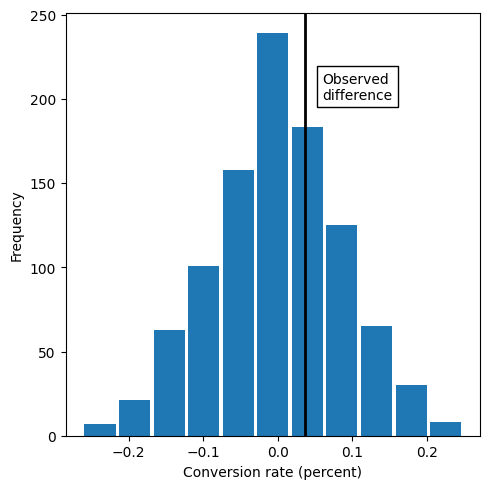

In [ ]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588)
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**p-value untuk conversion rate**

Proporsi pengacakan yang selisihnya lebih besar dari selisih teramati. Hasilnya 0,332, artinya sekitar 33% pengacakan menghasilkan selisih sebesar itu hanya karena kebetulan. Perbedaan Price A dan B tidak signifikan.

In [ ]:
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


**Uji chi-square sebagai pembanding**

Data konversi disusun dalam tabel 2x2: tiap baris adalah satu harga, berisi jumlah konversi dan jumlah bukan konversi (total dikurangi konversi). `chi2_contingency` menguji apakah konversi bergantung pada harga. Karena yang ditanyakan satu arah, p-value dibagi dua. Hasilnya sekitar 0,35, mirip dengan permutation test (0,332), jadi kedua cara sepakat.

In [ ]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


**t-test untuk waktu kunjungan**

`ttest_ind` dengan `equal_var=False` adalah Welch's t-test, yaitu uji beda rata-rata dua kelompok tanpa mengasumsikan variansnya sama. p-value dibagi dua untuk uji satu arah. Hasilnya 0,1408, mirip dengan permutation test (0,121). Kesimpulannya sama: belum signifikan.

In [ ]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


**t-test dengan statsmodels**

Hasilnya sama dengan sel sebelumnya (0,1408), tetapi memakai `statsmodels`. Arah uji ditentukan dengan `alternative='smaller'`, yaitu menguji apakah rata-rata Page A lebih kecil dari Page B, sehingga p-value tidak perlu dibagi dua lagi.

In [ ]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


**Boxplot untuk empat halaman**

Dataset `four_sessions` dibaca ulang, lalu boxplot waktu kunjungan dibuat untuk tiap halaman (Page 1 sampai 4). Untuk lebih dari dua kelompok, pengujiannya tidak lagi memakai t-test, melainkan ANOVA.

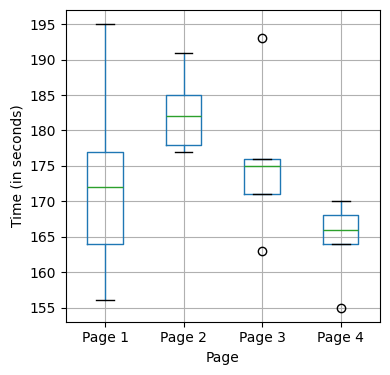

In [ ]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

**Melihat isi data `four_sessions`**

Lima baris pertama: kolom `Page` adalah halaman, kolom `Time` adalah waktu kunjungan. Tiap halaman punya 5 pengamatan.

In [ ]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


**Statistik uji untuk empat kelompok**

- `observed_variance`: variansi dari keempat rata-rata kelompok. Rata-ratanya 172,8; 182,6; 175,6; 164,6, dengan variansi 55,43. Semakin besar variansi, semakin berbeda rata-rata antar halaman.
- `perm_test`: mengacak seluruh nilai `Time` ke halaman mana pun, lalu menghitung variansi rata-rata kelompok lagi. Satu pengacakan memberi 18,95. Angka ini berubah tiap dijalankan.

In [ ]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
18.946666666666612


**Permutation test untuk ANOVA**

Pengacakan diulang 3000 kali. `Pr(Prob)` adalah proporsi pengacakan yang variansnya lebih besar dari variansi asli (55,43), yaitu p-value permutation test. Histogram menunjukkan variansi yang wajar muncul karena kebetulan, dan garis hitam adalah variansi asli. Bandingkan dengan p-value ANOVA di sel berikutnya.

Pr(Prob) 0.078


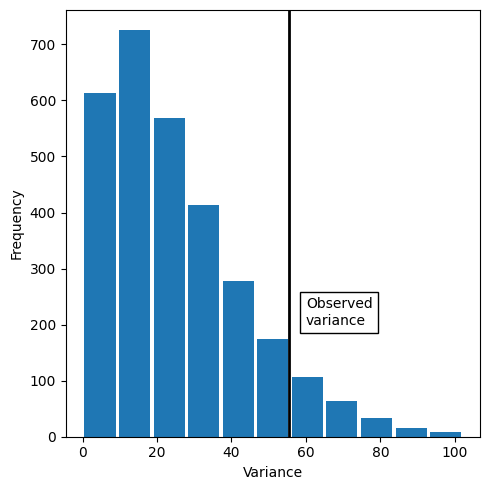

In [ ]:
random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**ANOVA lewat `statsmodels`**

Model `Time ~ Page` diuji dengan `anova_lm`. Hasilnya F = 2,74 dengan p-value 0,0776. Karena di atas 0,05, perbedaan rata-rata antar halaman **tidak signifikan**. Nilai ini dekat dengan hasil permutation test.

In [ ]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()

aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


`stats.f_oneway` dari `scipy.stats` dipakai untuk **One-Way ANOVA** (Analysis of Variance), yaitu uji untuk mengetahui apakah ada perbedaan rata-rata yang signifikan antara tiga kelompok independen atau lebih.

Catatan hasil: pada sel kode di bawah, `res.statistic` dan `res.pvalue` dibagi 2, sehingga tercetak F = 1,3699 dan p = 0,0388. Padahal hasil ANOVA yang benar sama dengan sel `anova_lm` di atas, yaitu F = 2,7398 dan p = 0,0776. Hapus `/ 2` di kedua baris itu untuk mendapat hasil yang benar.

In [ ]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time,
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic / 2:.4f}')
print(f'p-value: {res.pvalue / 2:.4f}')

F-Statistic: 1.3699
p-value: 0.0388


One-Way ANOVA dipakai ketika ada satu variabel kategorik (dengan dua kelompok atau lebih) dan satu variabel kontinu sebagai hasilnya. Uji ini menunjukkan apakah setidaknya satu rata-rata kelompok berbeda secara signifikan dari yang lain.

**Data klik untuk tiga judul berita**

Tabel jumlah klik dan tidak klik untuk tiga judul. Tiap judul ditampilkan 1000 kali: Headline A 14 klik, B 8 klik, C 12 klik. Baris `Click` adalah jumlah klik dan baris `No-click` adalah jumlah tidak klik.

In [ ]:

# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


**Nilai yang diharapkan jika tiga judul sama saja**

Jika tidak ada perbedaan antar judul, jumlah klik tiap judul diharapkan sama, yaitu rata-rata ketiganya: 11,33 klik dan 988,67 tidak klik. Tabel ini dipakai sebagai pembanding untuk mengukur seberapa jauh data asli menyimpang.

In [ ]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


**Chi-square dengan resampling**

- `box`: 3000 tayangan (3 judul x 1000), berisi 34 klik (1) dan sisanya tidak klik (0). Isinya diacak.
- `chi2`: menjumlahkan (observasi - harapan)² / harapan untuk semua sel. Semakin besar, semakin jauh data dari kondisi "semua judul sama".
- `perm_fun`: mengacak `box`, membagi jadi tiga kelompok 1000, lalu menghitung chi-square.

Pengacakan diulang 2000 kali. Statistik asli 1,6659 dan p-value resampling 0,4660, artinya perbedaan klik antar judul bisa sepenuhnya terjadi karena kebetulan.

In [ ]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4660


**Chi-square dengan rumus (scipy)**

`chi2_contingency` menghitung statistik chi-square dan p-value dari tabel `clicks` langsung dengan rumus. Statistik chi-square sama (1,6659) dan p-value 0,4348 mirip dengan resampling (0,4660). Jadi cara resampling dan cara rumus memberi kesimpulan yang sama.

In [ ]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


**Variasi resampling**

Mirip sel sebelumnya, tetapi setiap kelompok 1000 tayangan diambil sendiri-sendiri dari `box` memakai `random.sample`. Hasilnya p-value 0,4845, dekat dengan hasil sebelumnya. Jika diulang, angka bisa sedikit berubah karena acak.

In [ ]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4845


**Bentuk distribusi chi-square**

Menggambar kurva distribusi chi-square untuk derajat kebebasan (df) 1, 2, 5, 10, dan 20. Pada df kecil, kurva menurun tajam dari kiri. Semakin besar df, kurva makin bergeser ke kanan dan makin simetris. Distribusi inilah yang dipakai untuk mencari p-value dari statistik chi-square.

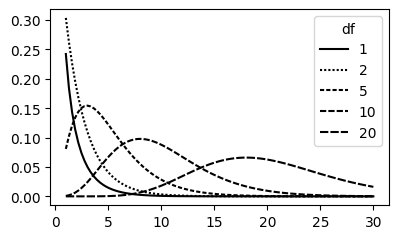

In [ ]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

**Ukuran Sampel (Sample Size)**
- **Definisi:** jumlah individu atau observasi yang dikumpulkan dalam studi.
- **Kenapa penting:** sampel yang lebih besar lebih mewakili populasi dan mengurangi pengaruh fluktuasi acak.
- **Contoh:** mengukur 100 mahasiswa memberi rata-rata tinggi badan yang lebih akurat daripada hanya 5 mahasiswa.

**Power**
- **Definisi:** peluang uji statistik mendeteksi efek atau perbedaan yang memang ada.
- **Kenapa penting:** power tinggi menurunkan peluang Type II error (melewatkan efek yang nyata), sehingga hasil studi lebih bisa dipercaya.
- **Contoh:** saat menguji obat baru, power tinggi berarti ada peluang besar membuktikan obat itu lebih efektif jika memang benar demikian.

**Data Imanishi**

Nama kolom dibersihkan dari spasi, lalu frekuensi tiap digit digambar sebagai grafik batang. Grafik ini menunjukkan sebaran digit pada data, yang bisa diperiksa apakah wajar atau tidak (misalnya dengan chi-square).

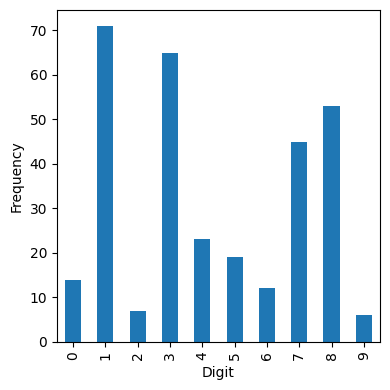

In [ ]:
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Ukuran sampel untuk selisih kecil**

Analisis power: berapa sampel yang dibutuhkan untuk mendeteksi bahwa conversion rate naik dari 1,1% ke 1,21% (naik sekitar 10%)?
- `proportion_effectsize`: mengubah dua proporsi menjadi satu angka effect size.
- `solve_power`: mencari ukuran sampel dengan tingkat signifikansi 5% (`alpha=0.05`) dan power 80% (`power=0.8`), uji satu arah.

Hasilnya sekitar **116.602 per kelompok**. Selisih yang kecil membutuhkan sampel sangat besar.

In [ ]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.391


**Ukuran sampel untuk selisih lebih besar**

Sama seperti sel sebelumnya, tetapi targetnya conversion rate naik dari 1,1% ke 1,65% (naik 50%). Sampel yang dibutuhkan hanya sekitar **5.488 per kelompok**. Semakin besar selisih yang ingin dideteksi, semakin sedikit sampel yang dibutuhkan.

In [ ]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408
